# Day5: 인공지능 컴퓨터 비젼

## 학습 내용
1. Image classification 이해
2. GoogleNet 사용하기
3. ResNet 사용하기

In [2]:
# 파이토치 관련 라이브러리
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn, optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader

In [3]:
# warning 표시 끄기
import warnings
warnings.simplefilter('ignore')

# 기본 폰트 사이즈 변경
plt.rcParams['font.size'] = 14

# 기본 그래프 사이즈 변경
plt.rcParams['figure.figsize'] = (4,4)

# 기본 그리드 표시
# 필요에 따라 설정할 때는, plt.grid()
plt.rcParams['axes.grid'] = True
plt.rcParams["grid.linestyle"] = ":"

# 마이너스 기호 정상 출력
plt.rcParams['axes.unicode_minus'] = False

# 넘파이 부동소수점 자릿수 표시
np.set_printoptions(suppress=True, precision=4)

In [ ]:
# GPU 디바이스 할당

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


### 공통 함수 불러오기

## 데이터 준비

In [5]:
# 분류 클래스명 정의

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 분류 클래스 수는 10
n_output = len(classes)

In [6]:
# Transforms 정의

# 학습 데이터용 
transform = transforms.Compose([
  transforms.Resize(112),
  transforms.ToTensor(),
  transforms.Normalize(0.5, 0.5), 
])

In [7]:
# 데이터 취득용 함수 dataset

data_root = './data'

train_set = datasets.CIFAR10(
    root = data_root, 
    train = True,
    download = True, 
    transform = transform)

# 검증 데이터셋
test_set = datasets.CIFAR10(
    root = data_root, 
    train = False, 
    download = True, 
    transform = transform)

In [8]:
# 배치 사이즈 지정
batch_size = 50

# 데이터로더

# 훈련용 데이터로더
# 훈련용이므로 셔플을 True로 설정함
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)

# 검증용 데이터로더
# 검증용은 셔플이 필요하지 않음
test_loader = DataLoader(test_set,  batch_size=batch_size, shuffle=False) 

## 1. GoogLeNet 불러 오기

### 모델 불러오기

In [ ]:
# dir(models)
weights = models.GoogLeNet_Weights.IMAGENET1K_V1 # 이미지 모델의 가중치 가져오기

# 이미지 모델 불러오기
net = models.googlenet(weights=weights) # 가중치 설정
net = net.to(device) # CPU 또는 GPU 등 연산할 기기 세팅
# 모델 개요 표시 1
print(net)

GoogLeNet(
  (conv1): BasicConv2d(
    (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (conv2): BasicConv2d(
    (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (conv3): BasicConv2d(
    (conv): Conv2d(64, 192, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(192, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
  (inception3a): Inception(
    (branch1): BasicConv2d(
      (conv): Conv2d(192, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track

### 파인 튜닝 없이 사용하기

In [ ]:
### Step 2: Read image
## rgb format, <class 'torch.Tensor'>
from torchvision.io import read_image

net.eval() # 실습에서는 학습된 데이터를 사용하므로, 학습하지 않도록 설정

filename = "./fig/beagle.jpg"
img = read_image(filename) # torch.Size([3, 366, 640]) 
img = img.to(device) # GPU 로 이미지 보내기

##
print("img type = ", type(img))
print("img shape = ", img.shape) # torch.Size([3, 366, 640]))

img type =  <class 'torch.Tensor'>
img shape =  torch.Size([3, 366, 640])


### 영상 변환

In [ ]:
# preprocess
# Scaling pixel values down to the [0, 1] range from their original [0, 255] range before applying normalization.
# ImageClassification(
#     crop_size=[224]
#     resize_size=[256]
#     mean=[0.485, 0.456, 0.406]
#     std=[0.229, 0.224, 0.225]
#     interpolation=InterpolationMode.BILINEAR
# )

preprocess = weights.transforms() # image transformation # 이미지 사이즈 조정
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


### 변환 영상 확인하기

torch.Size([1, 3, 224, 224])


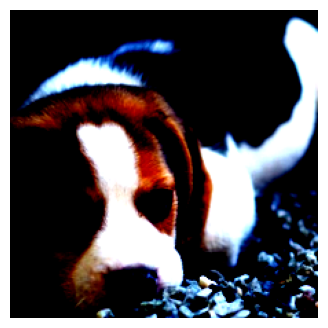

In [ ]:
# 'preprocess' 함수를 사용하여 입력 이미지(img)를 표준화하고 텐서로 변환
# 이 함수는 크기 조정, 정규화(예: 평균/표준 편차 사용) 등의 작업을 수행
batch = preprocess(img).unsqueeze(0).to(device) # 사이즈 조정한 이미지를 unsqueeze 함수 이용해 1차원을 늘린 다음, 연산 수행할 기기에 적재
# (1: 배치 크기, C: 채널 수, H: 높이, W: 너비)
print(batch.shape)

# 배치(batch) 텐서에서 실제 이미지 데이터를 추출
# '[0]'을 사용하여 배치 크기 차원(크기 1)을 제거하여 (C, H, W) 형태로 변환
# 이미지 출력에 배치 크기는 필요없기 때문에 제거
processed_img = batch.data[0]
# 'torch.clamp(..., 0, 1)'는 픽셀 값의 범위를 [0, 1] 사이로 제한
plt_img = torch.clamp(processed_img.permute(1, 2, 0), 0, 1) # PyTorch 텐서 → 이미지 시각화용 텐서 
# permute 함수 이용해 시각화위해 Tensor의 차원 순서를 변경
# (C, H, W)  →  (H, W, C)

# plt_img.shape
plt.imshow(plt_img.cpu().numpy())
plt.grid(visible = None)
plt.axis("off")
plt.show()

In [ ]:
# Step 5: Use the model and print the predicted category
net = net.to(device)
# print('prediction shape = ', prediction)
# prediction 값들 중 가장 높은 값을 사용

# softmax(1)를 적용하여 로짓을 확률 분포로 변환
# softmax 는 확률로 변경해주는 함수
prediction = net(batch).softmax(dim = 1) # (1, 1000)

# argmax()는 가장 큰 값의 인덱스를 반환하며, 배치 차원을 유지
# .item()은 결과 텐서(예: 크기 1)에서 파이썬 정수 값(스칼라)만 추출
# prediction.max(1)
class_id = prediction.argmax().item() # 예측 값들 중 가장 높은 학률 값의 위치 번호(인덱스)만 추출
print("class id = ", class_id)

class id =  162


### 결과 확인 하기

In [ ]:
display("category = \n", weights.meta["categories"]) # weights.meta[categories] 는 학습에 사용한 카테고리들을 보여준다.
print("category number = ", len(weights.meta["categories"]))

'category = \n'

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich',
 'brambling',
 'goldfinch',
 'house finch',
 'junco',
 'indigo bunting',
 'robin',
 'bulbul',
 'jay',
 'magpie',
 'chickadee',
 'water ouzel',
 'kite',
 'bald eagle',
 'vulture',
 'great grey owl',
 'European fire salamander',
 'common newt',
 'eft',
 'spotted salamander',
 'axolotl',
 'bullfrog',
 'tree frog',
 'tailed frog',
 'loggerhead',
 'leatherback turtle',
 'mud turtle',
 'terrapin',
 'box turtle',
 'banded gecko',
 'common iguana',
 'American chameleon',
 'whiptail',
 'agama',
 'frilled lizard',
 'alligator lizard',
 'Gila monster',
 'green lizard',
 'African chameleon',
 'Komodo dragon',
 'African crocodile',
 'American alligator',
 'triceratops',
 'thunder snake',
 'ringneck snake',
 'hognose snake',
 'green snake',
 'king snake',
 'garter snake',
 'water snake',
 'vine snake',
 'night snake',
 'boa constrictor',
 'rock python',
 'Indian cobr

category number =  1000


In [ ]:
# 앞 단계에서 예측된 정수 값인 'class_id'를 이 리스트의 인덱스로 사용하여
# 해당 ID에 해당하는 클래스의 이름을 추출
category_name = weights.meta["categories"][class_id]
print(category_name)

# prob = prediction[0][class_id].item() # 해당 예측 값의 확률 보기
# print(prob)


'beagle'

## 2. ResNet (전이 학습)

### 모델 불러 오기

In [ ]:
# 사전 학습 모델 불러오기
weights = models.ResNet18_Weights.IMAGENET1K_V1 # 이미지 모델 가중치 가져오기
net = models.resnet18(weights = weights) # 가중치 설정

print(net)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 최종 레이어 함수 교체하기

In [ ]:
## 레이어 변경
fc_in_features = net.fc.in_features # Input Layer 는 그대로 유지
n_output = 10 # Output Layer 를 10개로 변경

# 최종 레이어 함수 교체
net.fc = nn.Linear(fc_in_features, n_output)

# 모델 개요 표시 1

# 모델 GPU 로 보내기
net = net.to(device)
print(net)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

### 학습 파라메터 설정
- Data: CIFAR10
- Model: ResNet 10 transfer learning

In [ ]:
# 학습률
lr = 0.001

# 손실 함수 정의
criterion = nn.CrossEntropyLoss() # 이미지는 결과 값이 있는지 없는지(0 또는 1) 2가지이므로 손실 함수는 CE(CrossEntropy) 를 사용한다.

# 최적화 함수 정의
optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9) # 경사하강법 사용
# momentum 을 넣으면 결과가 좀 더 좋아진다.

# history 파일 초기화
history = np.zeros((0, 5))

# 학습
num_epochs = 5 # 5번 학습 수행

In [ ]:
batch_size = 50 # 5만개의 데이터들 중 50 개씩 데이터 분할

train_loader = DataLoader ( # 학습할 데이터는 1000개 세트
    train_set,
    batch_size = batch_size,
    shuffle = True
)

test_loader = DataLoader ( # 테스트 데이터는 200개 세트
    test_set,
    batch_size = batch_size,
    shuffle = False
)

### ResNet 전이 학습

In [ ]:
# tqdm 라이브러리 임포트
from tqdm.notebook import tqdm


# 데이터를 갖고 학습 수행

# 반복 계산 메인 루프
for epoch in range(num_epochs):
    train_acc, train_loss = 0, 0
    val_acc, val_loss = 0, 0

    net.train()
    # 훈련 페이즈
    for inputs, labels in tqdm(train_loader):

        # GPU로 전송
        inputs = inputs.to(device)
        labels = labels.to(device)
    
        # 경사 초기화
        optimizer.zero_grad()

        # 예측 계산
        outputs = net(inputs)

        # 손실 계산
        loss = criterion(outputs, labels)

        # 경사 계산
        loss.backward()
    
        # 파라미터 수정
        optimizer.step()

        # 예측 라벨 산출
        predicted = torch.max(outputs, 1)[1]

        # 손실과 정확도 계산
        train_loss += loss.item()
        train_acc += (predicted == labels).float().mean().item()


# -------------------------------------------------------------------------
# 학습 기반으로 테스트 데이터를 갖고 실제 작업 수행

    # scheduler.step()
    # 예측 페이즈
    net.eval()

    with torch.no_grad(): # 메모리 절약위해 torch.no_grad() 사용
        for inputs_test, labels_test in test_loader:

            inputs_test = inputs_test.to(device)
            labels_test = labels_test.to(device)

            # 예측 계산
            outputs_test = net(inputs_test)

            # 손실 계산
            loss_test = criterion(outputs_test, labels_test)

            # 예측 라벨 산출
            predicted_test = torch.max(outputs_test, 1)[1]

            # 손실과 정확도 계산
            val_loss +=  loss_test.item()
            val_acc +=  (predicted_test == labels_test).float().mean().item()

    # 평가 결과 산출, 기록
    train_acc = train_acc /len(train_loader)
    val_acc = val_acc / len(test_loader)
    train_loss = train_loss /len(train_loader)
    val_loss = val_loss /len(test_loader)
    # current_lr = optimizer.param_groups[0]['lr']
    print (f'Epoch: {epoch}, loss: {train_loss:.5f} acc: {train_acc:.5f} val_loss: {val_loss:.5f}, val_acc: {val_acc:.5f}')
    item = np.array([epoch , train_loss, train_acc, val_loss, val_acc])
    # print(f"lr = {current_lr}")
    history = np.vstack((history, item))

  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch: 0, loss: 0.43809 acc: 0.85380 val_loss: 0.24122, val_acc: 0.91530


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch: 1, loss: 0.17148 acc: 0.94306 val_loss: 0.21125, val_acc: 0.92660


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch: 2, loss: 0.09244 acc: 0.97054 val_loss: 0.19714, val_acc: 0.93480


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch: 3, loss: 0.05046 acc: 0.98538 val_loss: 0.20349, val_acc: 0.93740


  0%|          | 0/1000 [00:00<?, ?it/s]

Epoch: 4, loss: 0.02802 acc: 0.99222 val_loss: 0.20671, val_acc: 0.93880


### 모델 저장

In [ ]:
# net.state_dict()는 신경망 모델 'net'의 모든 학습 가능한 매개변수(가중치와 편향)를
# 포함하는 딕셔너리(Dictionary)를 반환
# 모델 구조 자체가 아닌, '학습된 가중치 값'만을 저장하는 것이 일반적이며 권장

torch.save(net.state_dict(), "resnet_pretrained_5ep.pt")
# net.load_state_dict(torch.load("resnet_pretrained_10ep.pt"))
# net.eval()